In [85]:
import os
import rasterio as rio
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.path as mpth
from pathlib import Path

import shapefile as shp
import pickle as pk
import geopandas as gpd
from rasterio.features import rasterize
from rasterio.transform import from_origin
from scipy.ndimage import binary_erosion

from deep_translator import GoogleTranslator
translator = GoogleTranslator(source='nl', target='en')


import Functions
import importlib

importlib.reload(Functions)

<module 'Functions' from '/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/Functions/Functions.py'>

In [86]:
app_path = Functions.get_input_path() / 'App'
input_path = app_path / 'Data' / 'Ground_Campaign'

sentinel_path = Path('/media')/ 'frank' / 'USB' / 'SCUOLA' / 'App' / 'COHERENCIA'

shape_path = input_path / 'Flevoland_data' / 'Data_25_fields' / 'Flevoland-fields-Shapefiles'

path: /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA


In [87]:
img_dates = Functions.read_dates_from_stack(sentinel_path)

shapes = next(shape_path.glob('*.shp'))
hdrs = list(sentinel_path.glob('*06days*.hdr'))

In [88]:
gdf = gpd.read_file(shapes)
virgin_parcel = gdf[gdf['CAT_GEWASC'] == 'Braakland']
#display(virgin_parcel)
virgin_parcel = virgin_parcel.to_crs("epsg:32631")

In [112]:
parcels_types = np.unique(gdf['GWS_GEWAS'])
display(parcels_types)

array(['Aardappelen, bestrijdingsmaatregel AM', 'Aardappelen, consumptie',
       'Aardappelen, poot NAK', 'Aardappelen, poot TBM',
       'Aardappelen, zetmeel', 'Aardbeien op stellingen, productie',
       'Aardbeien open grond, productie',
       'Aardbeien open grond, vermeerdering', 'Aardperen',
       'Agrarisch natuurmengsel', 'Appelen. Aangeplant lopende seizoen.',
       'Appelen. Aangeplant voorafgaande aan lopende seizoen.',
       'Asperges, oppervlakte die nog geen productie oplevert',
       'Asperges, oppervlakte die productie oplevert',
       'Augurk, productie', 'Bessen, rode', 'Bieten, suiker-',
       'Bieten, voeder-', 'Bladkool', 'Bladrammenas', 'Blauwmaanzaad',
       'Bloemkool, winter, productie', 'Bloemkool, zomer, productie',
       'Bloemkool, zomer, zaden en opkweekmateriaal',
       'Bloemzaden open grond', 'Boerenkool, productie', 'Bonen, bruine-',
       'Bonen, tuin- (droog te oogsten) (geen consumptie)',
       'Bonen, tuin- (groen te oogsten)', 'Bos z

In [89]:
virgin_parcel.set_index(virgin_parcel['OBJECTID'],inplace=True)
virgin_parcel = virgin_parcel.drop('OBJECTID', axis=1)
#display(virgin_parcel)

In [90]:
mypoly = virgin_parcel.to_dict(orient='index')

In [95]:
display(type(mypoly))

dict

In [98]:
X_geo, Y_geo = Functions.axes_from_metadata(hdrs[0])

# Risoluzione dei pixel (assumendo Sentinel-1/2 tipicamente 10m o vedi i tuoi dati)
# Calcoliamo il passo (pixel size) direttamente dai tuoi assi
res_x = X_geo[1] - X_geo[0]
res_y = Y_geo[1] - Y_geo[0] # Di solito è negativo perché l'immagine parte dall'alto

for key, feature in mypoly.items():
    poly = feature['geometry']
    
    if poly is None or poly.is_empty:
        print('Fuori')
        continue

    # 1. Bounding Box da Shapely
    xmin, ymin, xmax, ymax = poly.bounds

    # 2. Indici all'interno dell'immagine Sentinel
    idx_x = np.where((X_geo >= xmin) & (X_geo <= xmax))[0]
    idx_y = np.where((Y_geo >= ymin) & (Y_geo <= ymax))[0]

    if len(idx_x) == 0 or len(idx_y) == 0:
        print('fuori')
        continue

    # 3. Definiamo i range del subset (r0, r1, c0, c1)
    r0, r1 = idx_y.min(), idx_y.max() + 1
    c0, c1 = idx_x.min(), idx_x.max() + 1
    
    # Forma della matrice finale del subset
    out_shape = (r1 - r0, c1 - c0)

    # 4. TRASFORMAZIONE GEOSPAZIALE AFFINE (La chiave di rasterio)
    # Specifichiamo dove si trova l'angolo in alto a sinistra del nostro subset nel mondo reale
    # X_geo[c0] è la X minima del subset, Y_geo[r0] (o r1 a seconda del verso) è la Y massima.
    # Nota: assicurati che il punto di partenza sia l'angolo in alto a sinistra del pixel (top-left)
    top_left_x = X_geo[c0] - (res_x / 2)
    top_left_y = Y_geo[r0] - (res_y / 2) if res_y < 0 else Y_geo[r1-1] + (res_y / 2)
    
    transform = from_origin(top_left_x, top_left_y, abs(res_x), abs(res_y))

    # Crea direttamente una matrice booleana (True dentro il poligono, False fuori)
    mymask_sub = rasterize(
        [(poly, 1)],
        out_shape=out_shape,
        transform=transform,
        fill=0,
        dtype='uint8'
    )

    mymassk_sub = mymask_sub.astype(bool)
    # 6. Erosione binaria identica a prima per evitare l'effetto bordo
    mask_eroted = binary_erosion(mymask_sub, structure=np.ones((3,3))).astype(mymask_sub.dtype)
    
    # Salvataggio
    feature['mask_sub'] = mask_eroted
    feature['r_range'] = (r0, r1)
    feature['c_range'] = (c0, c1)

display(mypoly)

fuori
fuori
fuori
fuori


{1542114.0: {'CAT_GEWASC': 'Braakland',
  'GWS_GEWASC': '2300',
  'GEOMETRIE_': 399.93280864805786,
  'GEOMETRI_1': 8499.879564893014,
  'GWS_GEWAS': 'Onbeteelde grond vanwege een teeltverbod/ontheffing',
  'geometry': <POLYGON ((685518.377 5855808.758, 685471.913 5855849.878, 685543.801 585592...>},
 1554308.0: {'CAT_GEWASC': 'Braakland',
  'GWS_GEWASC': '3802',
  'GEOMETRIE_': 526.6978749715813,
  'GEOMETRI_1': 765.869063099809,
  'GWS_GEWAS': 'Tijdelijk onbeteelde grond, anders dan voor publieke werken',
  'geometry': <POLYGON ((689057.574 5835091.795, 688956.673 5835089.2, 688952.412 5835180....>,
  'mask_sub': array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [99]:
mypoly = {key: value for key, value in mypoly.items() if 'mask_sub' in value}

In [101]:
print(mypoly)

{1554308.0: {'CAT_GEWASC': 'Braakland', 'GWS_GEWASC': '3802', 'GEOMETRIE_': 526.6978749715813, 'GEOMETRI_1': 765.869063099809, 'GWS_GEWAS': 'Tijdelijk onbeteelde grond, anders dan voor publieke werken', 'geometry': <POLYGON ((689057.574 5835091.795, 688956.673 5835089.2, 688952.412 5835180....>, 'mask_sub': array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
      dtype=uint8), 'r_range': (np.int64(827), np.int64(836)), 'c_range': (np.int64(5517), np.int64(5535))}, 1567224.0: {'C

In [100]:
poly_stats = {k: {} for k in mypoly}

for file in hdrs:

    file_path = Path(file)
    file_stem = file_path.stem
    date = file_stem[:8] # Assumendo formato YYYYMMDD
    
    # 1. Apriamo il file (senza caricarlo in RAM!)
    img_obj = Functions.read_img2(file, '')

    # Determiniamo la polarizzazione dal nome del file
    pol = 'VH' if 'VH' in file_stem else 'VV'
    name = f'{date}_{pol}'

    print(f'Processing {pol} for date {date}...')

    for key in mypoly:
        r1, r2 = mypoly[key]['r_range']
        c1, c2 = mypoly[key]['c_range']
    
        # 2. LEGGIAMO SOLO IL RITAGLIO DAL DISCO
        # read_subregion( (r_start, r_end), (c_start, c_end) )
        radar_sub = img_obj.read_subregion((r1, r2), (c1, c2))
        
        # Pulizia dimensioni (da (H, W, 1) a (H, W))
        radar_sub = np.squeeze(radar_sub)
    
        # 3. Applichiamo la maschera erosa
        pixel_campo = radar_sub[mypoly[key]['mask_sub']]

        if len(pixel_campo) > 0:
            if name not in poly_stats[key]:
                poly_stats[key][name] = {}
            
            # Calcolo in lineare
            m_lin = np.mean(pixel_campo)
            s_lin = np.std(pixel_campo)
            
            # Salvataggio (puoi aggiungere anche la conversione in dB qui)
            poly_stats[key][name]['mean'] = m_lin
            poly_stats[key][name]['std'] = s_lin

        else:
            print(f"Attenzione: nessun pixel valido per {key} in {file_stem}")

# Pulizia manuale della memoria alla fine di ogni file (opzionale)

del img_obj

Processing VH for date 20170104...
Processing VV for date 20170104...
Processing VH for date 20170110...
Processing VV for date 20170110...
Processing VH for date 20170116...
Processing VV for date 20170116...
Processing VH for date 20170122...
Processing VV for date 20170122...
Processing VH for date 20170128...
Processing VV for date 20170128...
Processing VH for date 20170203...
Processing VV for date 20170203...
Processing VH for date 20170209...
Processing VV for date 20170209...
Processing VH for date 20170215...
Processing VV for date 20170215...
Processing VH for date 20170221...
Processing VV for date 20170221...
Processing VH for date 20170227...
Processing VV for date 20170227...
Processing VH for date 20170305...
Processing VV for date 20170305...
Processing VH for date 20170311...
Processing VV for date 20170311...
Processing VH for date 20170317...
Processing VV for date 20170317...
Processing VH for date 20170323...
Processing VV for date 20170323...
Processing VH for da

In [102]:
print(poly_stats[1554308.0])

{'20170104_VH': {'mean': np.float32(0.569112), 'std': np.float32(0.20262243)}, '20170104_VV': {'mean': np.float32(0.5815118), 'std': np.float32(0.22040807)}, '20170110_VH': {'mean': np.float32(0.38817933), 'std': np.float32(0.12157818)}, '20170110_VV': {'mean': np.float32(0.5723239), 'std': np.float32(0.10909152)}, '20170116_VH': {'mean': np.float32(0.4113629), 'std': np.float32(0.1683942)}, '20170116_VV': {'mean': np.float32(0.510995), 'std': np.float32(0.15026025)}, '20170122_VH': {'mean': np.float32(0.5390058), 'std': np.float32(0.07805027)}, '20170122_VV': {'mean': np.float32(0.57700086), 'std': np.float32(0.12116441)}, '20170128_VH': {'mean': np.float32(0.61838937), 'std': np.float32(0.06228216)}, '20170128_VV': {'mean': np.float32(0.63198847), 'std': np.float32(0.109399624)}, '20170203_VH': {'mean': np.float32(0.3735056), 'std': np.float32(0.13103467)}, '20170203_VV': {'mean': np.float32(0.52206105), 'std': np.float32(0.11907925)}, '20170209_VH': {'mean': np.float32(0.3359142), '

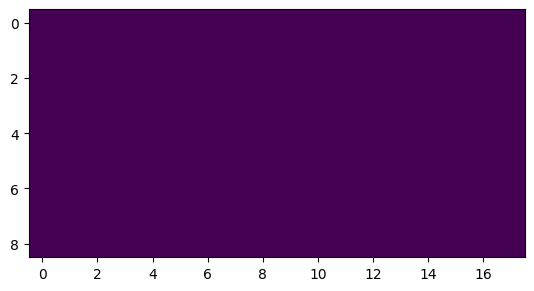

In [103]:
plt.imshow(mypoly[1554308.0]['mask_sub'])

(6346, 7025)



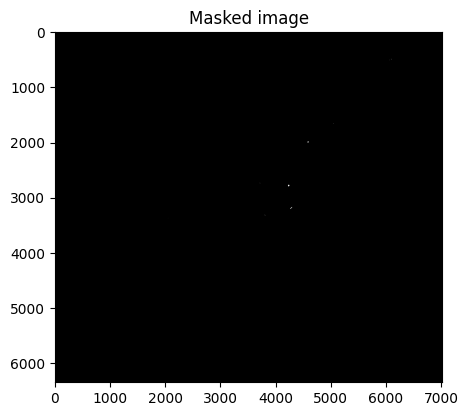

In [104]:
full_mask = np.zeros((len(Y_geo), len(X_geo)), dtype=bool)
print(full_mask.shape)

_, IMG = Functions.read_img(hdrs[0],'')

# 2. Inserisci la maschera piccola nella posizione corretta usando gli indici
# idx_y e idx_x definiscono le "coordinate matriciali" in cui incollare il pezzo
print()
for i in mypoly:

    full_mask[mypoly[i]['r_range'][0]:mypoly[i]['r_range'][1], 
              mypoly[i]['c_range'][0]:mypoly[i]['c_range'][1]] = mypoly[i]['mask_sub']

plt.figure(figsize=(5,5))
plt.imshow(full_mask, cmap='gray')
plt.title("Masked image")
plt.show()

In [105]:
rows = []
for roi, dates_dict in poly_stats.items():
    for date_band, stats in dates_dict.items():
        row = {'Code': roi, 'Date_Band': date_band}
        row.update(stats) # Aggiunge 'mean', 'std', ecc. come colonne
        rows.append(row)

df_stats = pd.DataFrame(rows)

df_stats[['Date', 'Band']] = df_stats['Date_Band'].str.split('_', expand=True)
df_stats['Date'] = pd.to_datetime(df_stats['Date'])
display(df_stats)

,Code,Date_Band,mean,std,Date,Band
0,1554308.0,20170104_VH,0.569112,0.202622,2017-01-04,VH
1,1554308.0,20170104_VV,0.581512,0.220408,2017-01-04,VV
2,1554308.0,20170110_VH,0.388179,0.121578,2017-01-10,VH
3,1554308.0,20170110_VV,0.572324,0.109092,2017-01-10,VV
4,1554308.0,20170116_VH,0.411363,0.168394,2017-01-16,VH
...,...,...,...,...,...,...
2347,2310990.0,20171212_VV,0.161612,0.079196,2017-12-12,VV
2348,2310990.0,20171218_VH,0.452264,0.289866,2017-12-18,VH
2349,2310990.0,20171218_VV,0.480446,0.346927,2017-12-18,VV
2350,2310990.0,20171224_VH,0.370948,0.262750,2017-12-24,VH


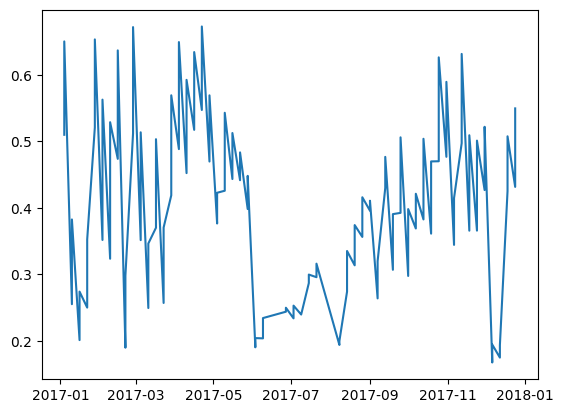

In [106]:
df_rainfall = pd.read_parquet(r'/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/rainfall_total.parquet')
df_rainfall.index = pd.to_datetime(df_rainfall.index, format='%Y-%m-%d')

Data trovata: 2017-01-04 00:00:00


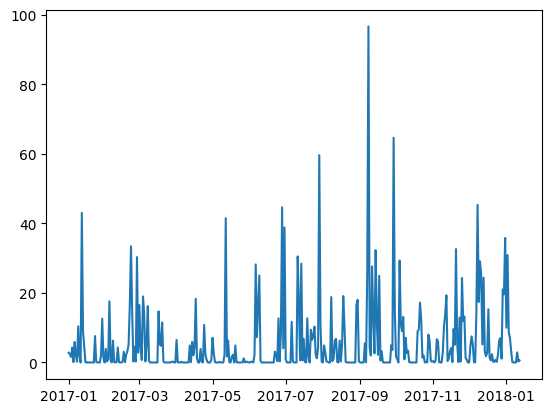

In [107]:
prima_corrispondenza = next((d for d in df_rainfall.index if np.datetime64(d) == img_dates[0]), None)

print(f"Data trovata: {prima_corrispondenza}")

df_filtered = df_rainfall.loc[prima_corrispondenza:]
plt.plot(df_rainfall)
df_weekly = df_filtered.resample('6D', label='left').sum()

/tmp/ipykernel_9750/767908433.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax1 = plt.subplots(figsize=(10, 6))


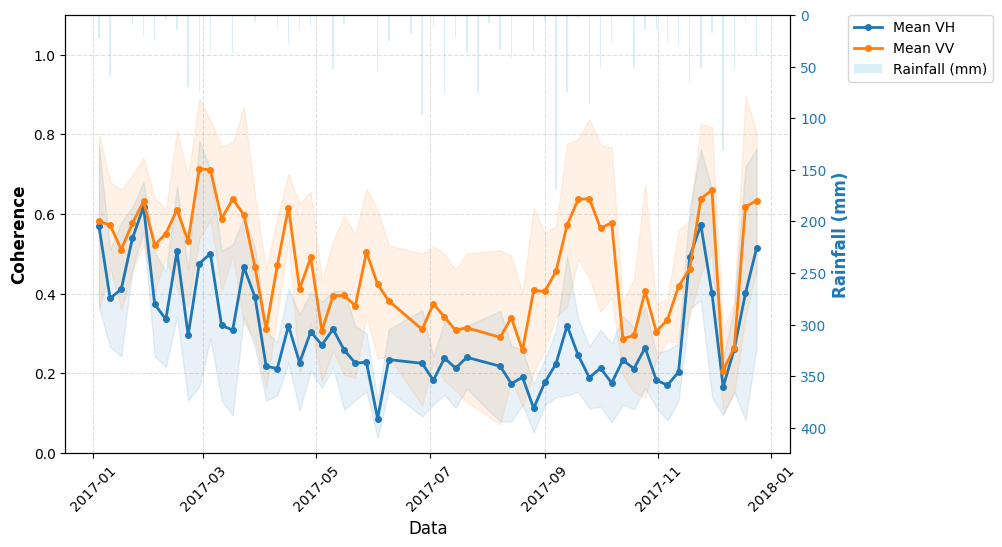

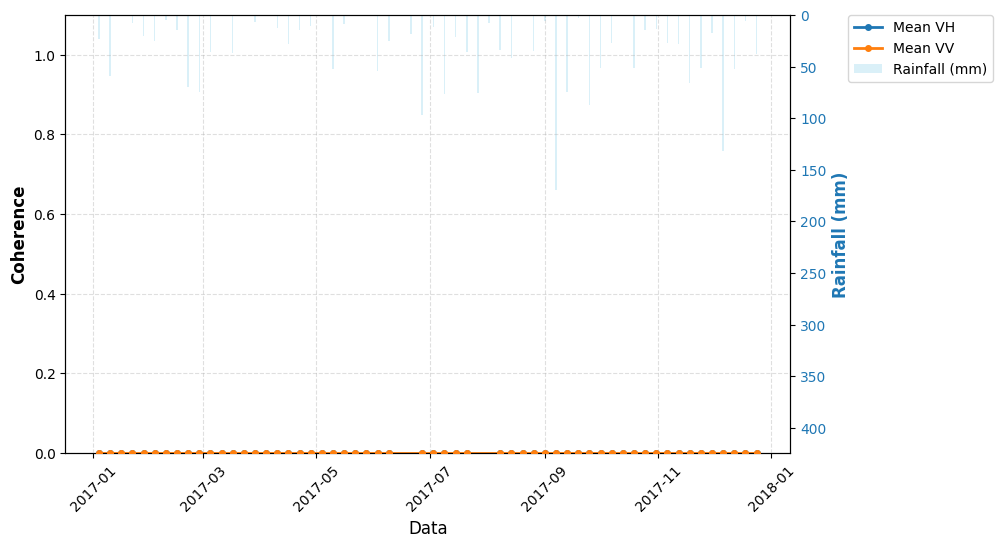

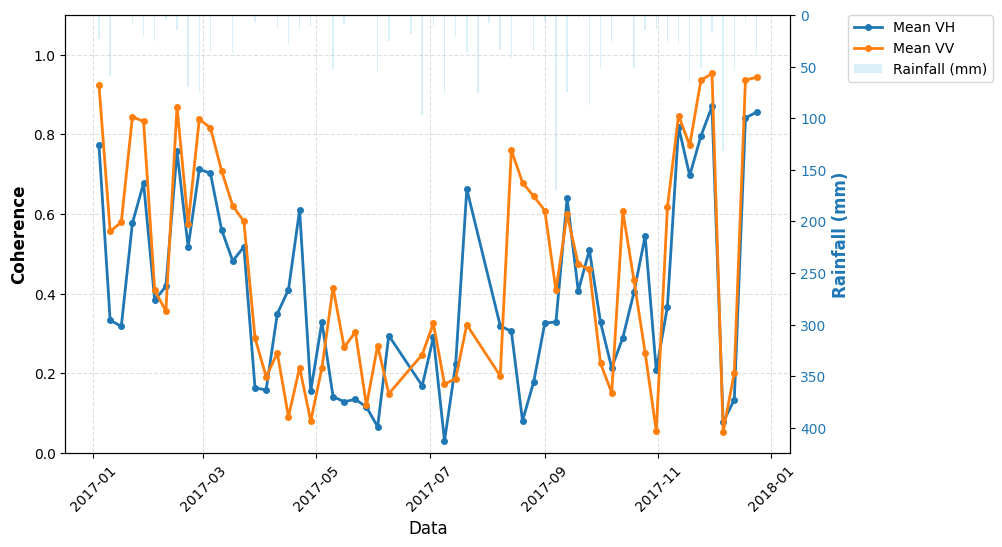

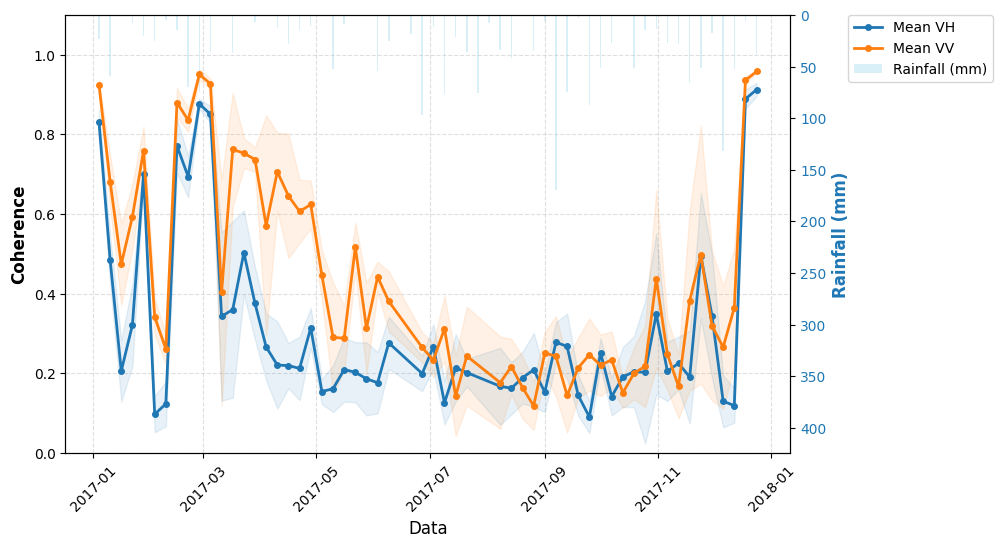

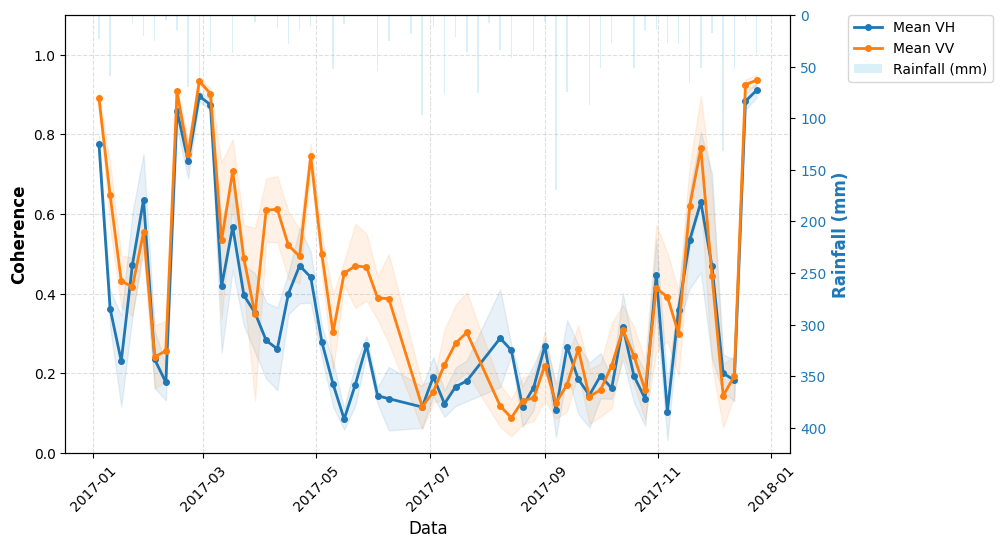

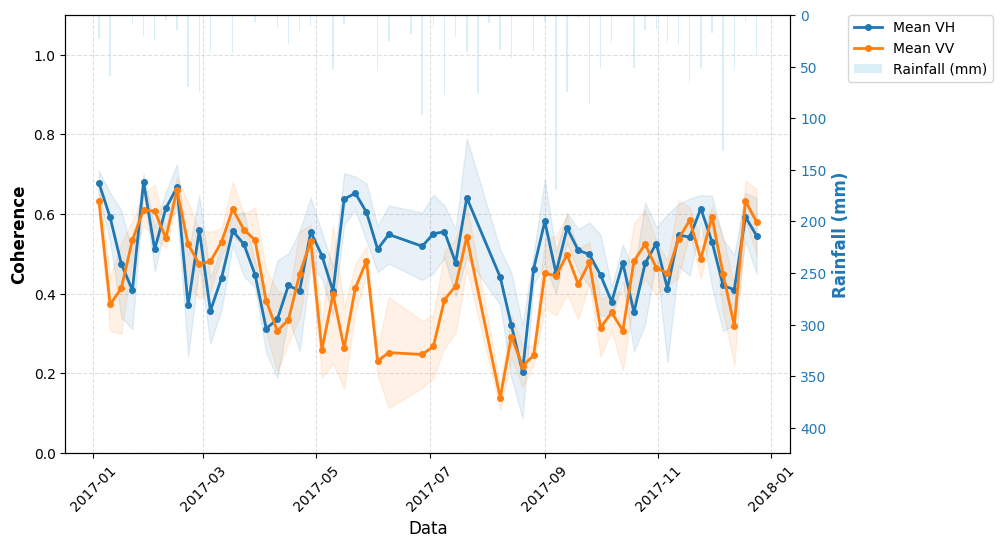

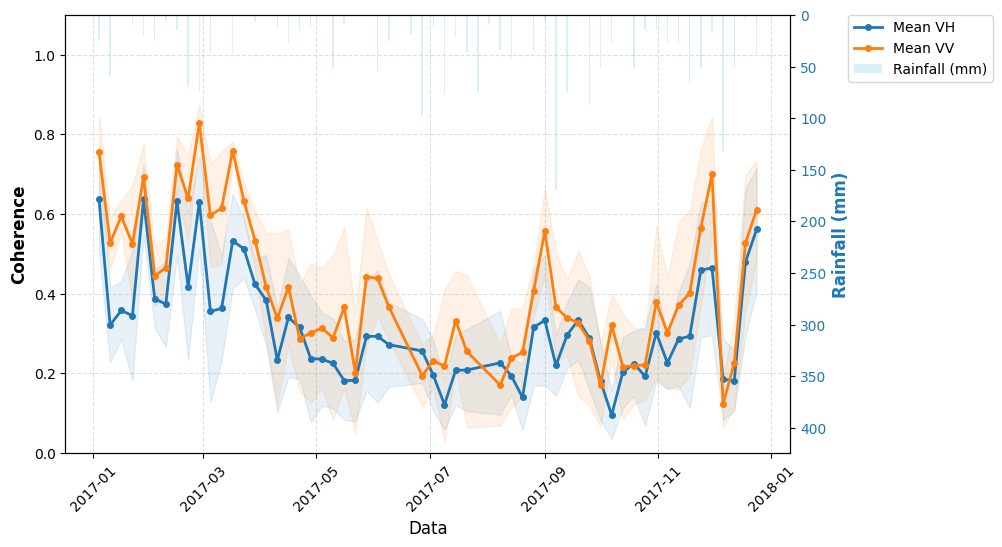

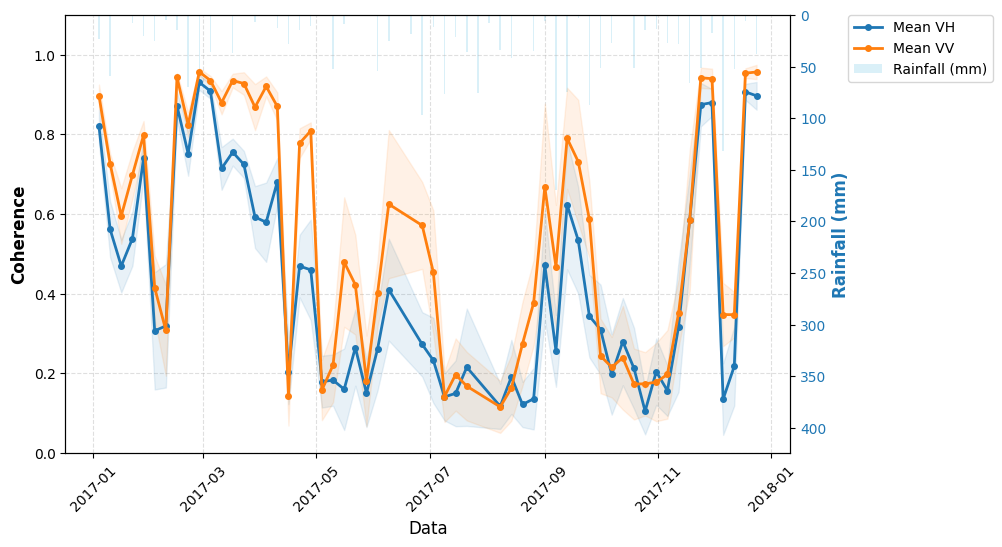

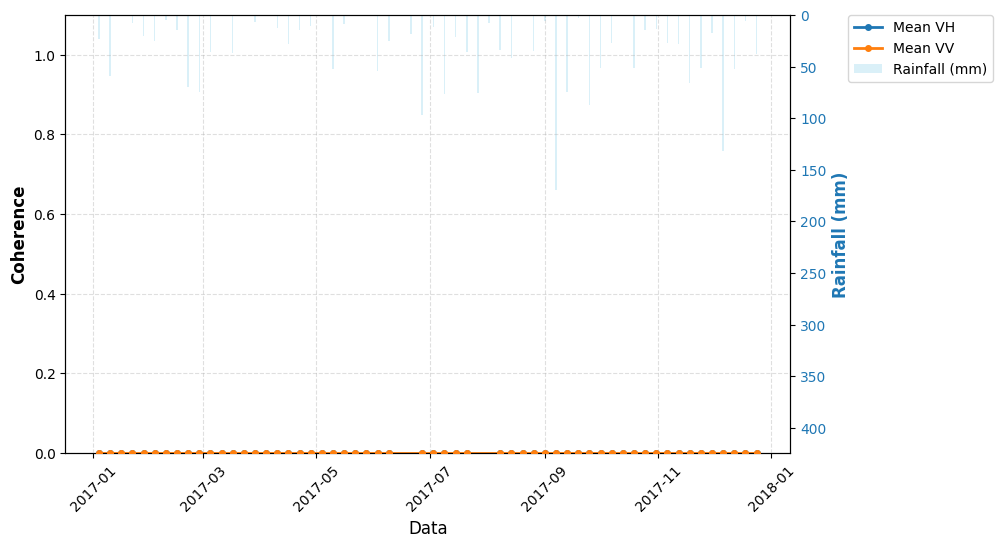

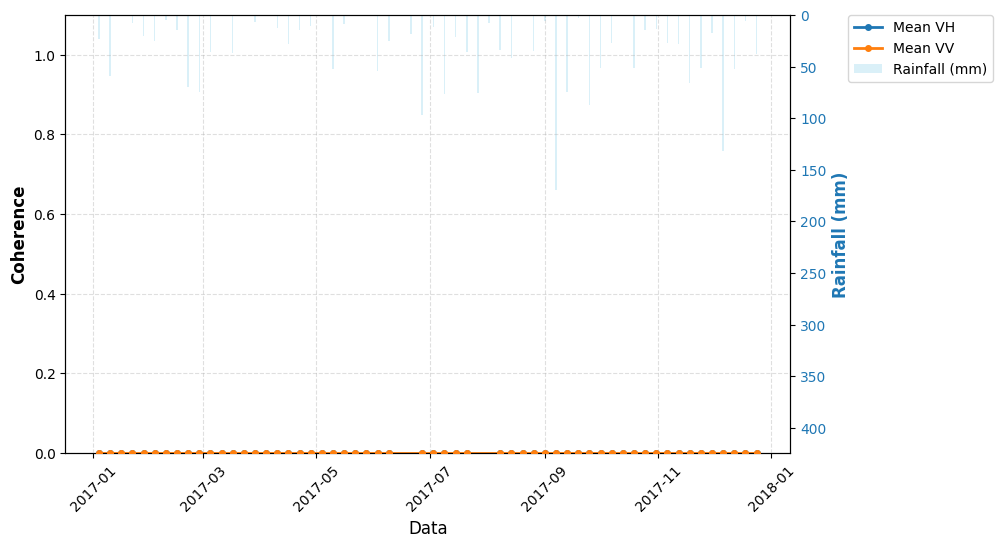

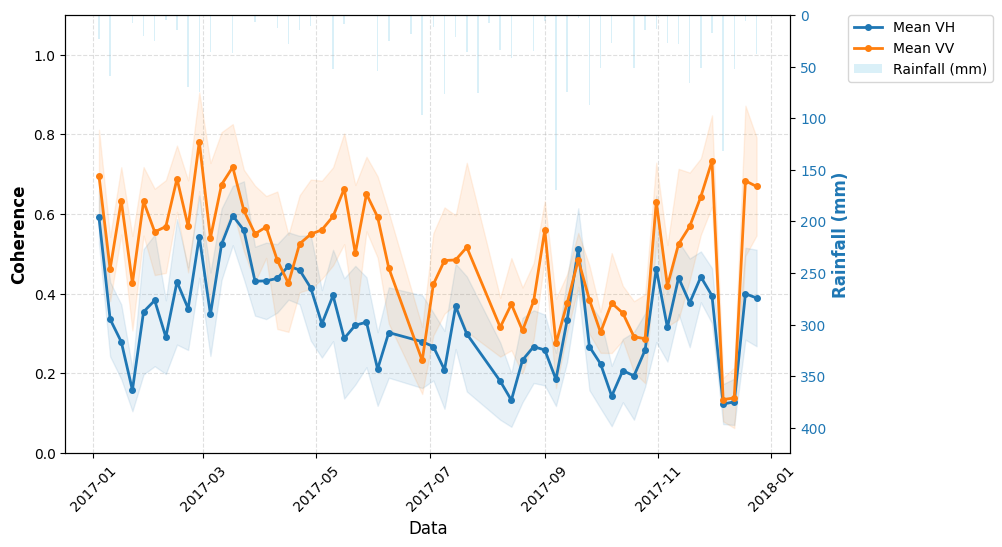

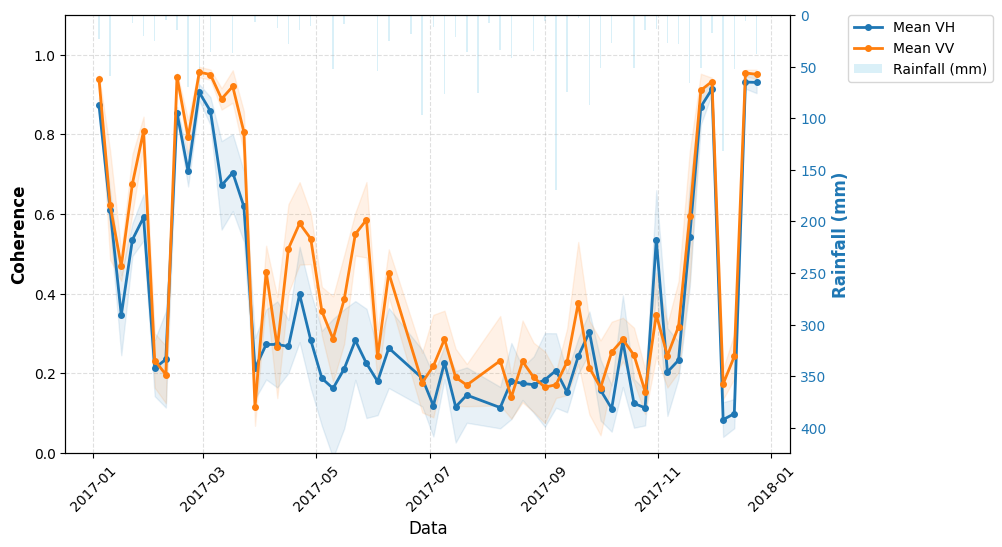

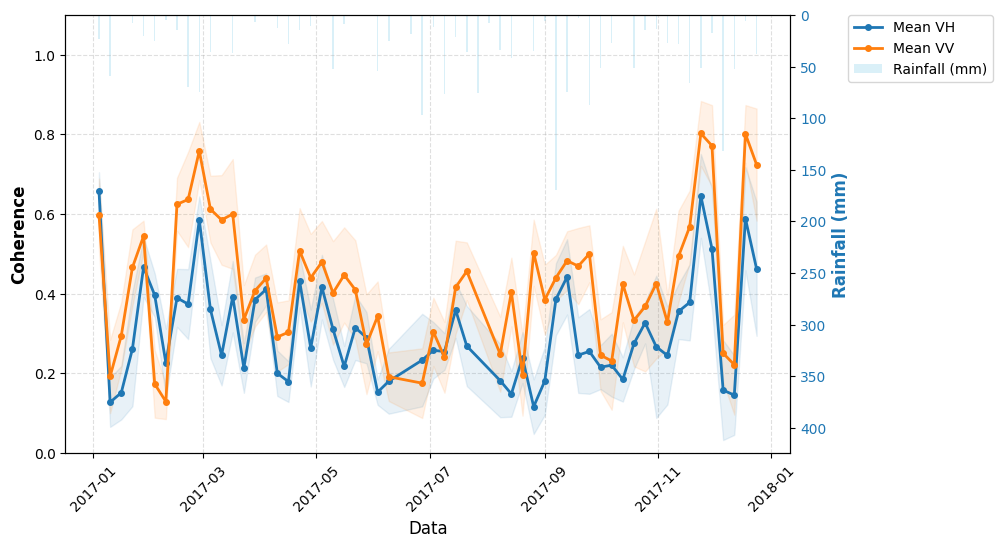

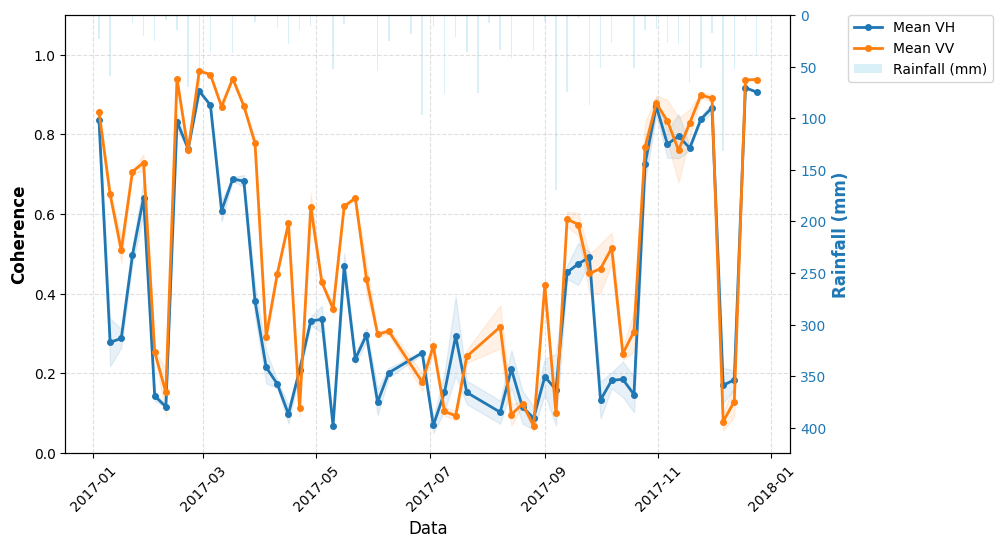

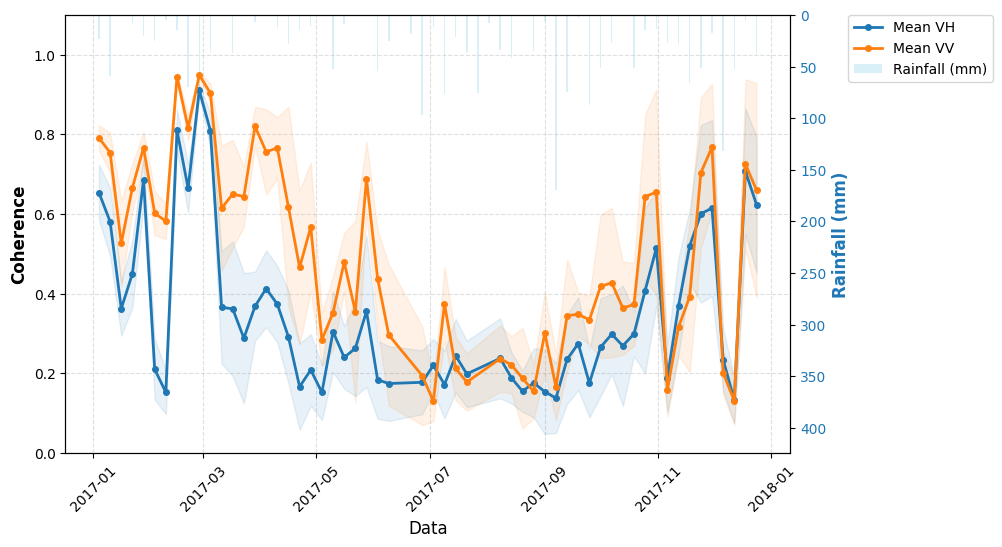

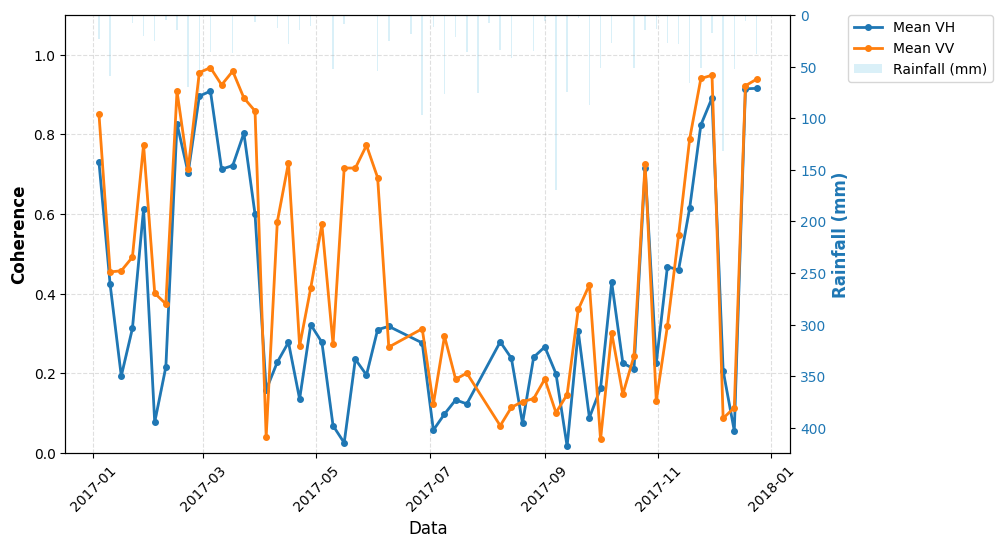

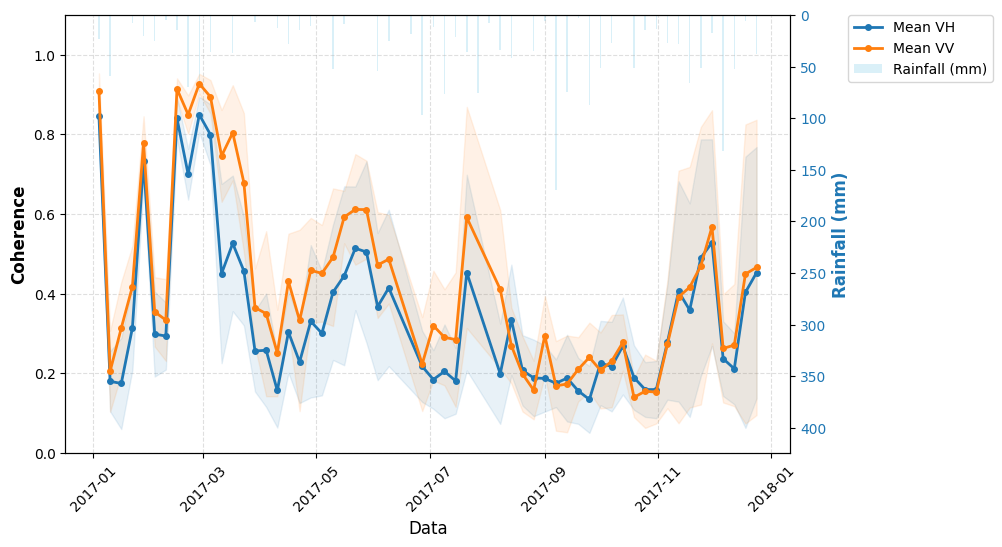

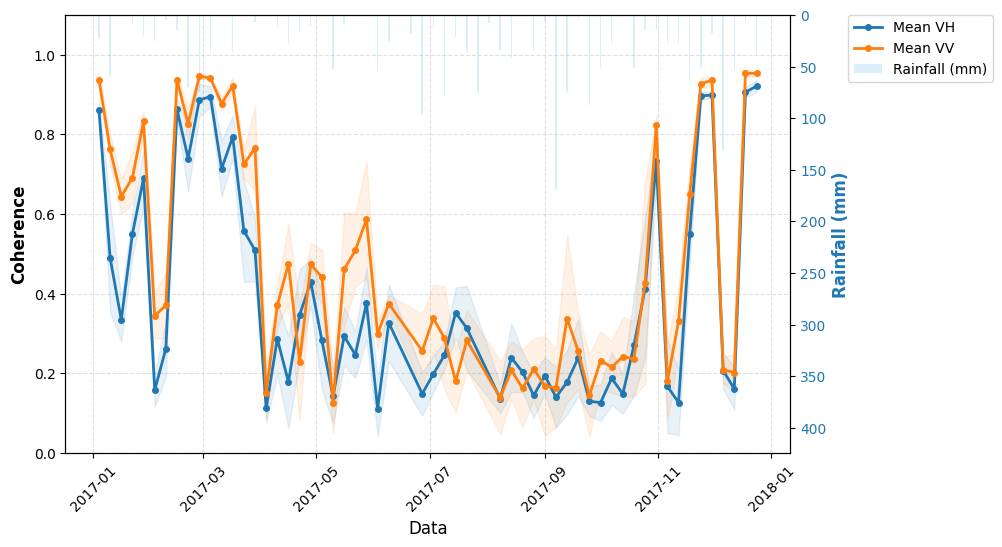

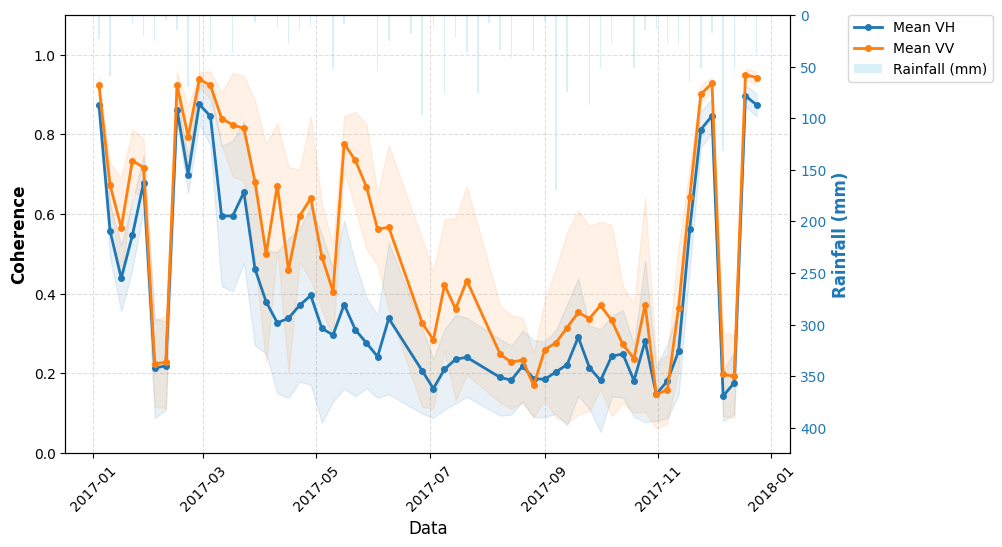

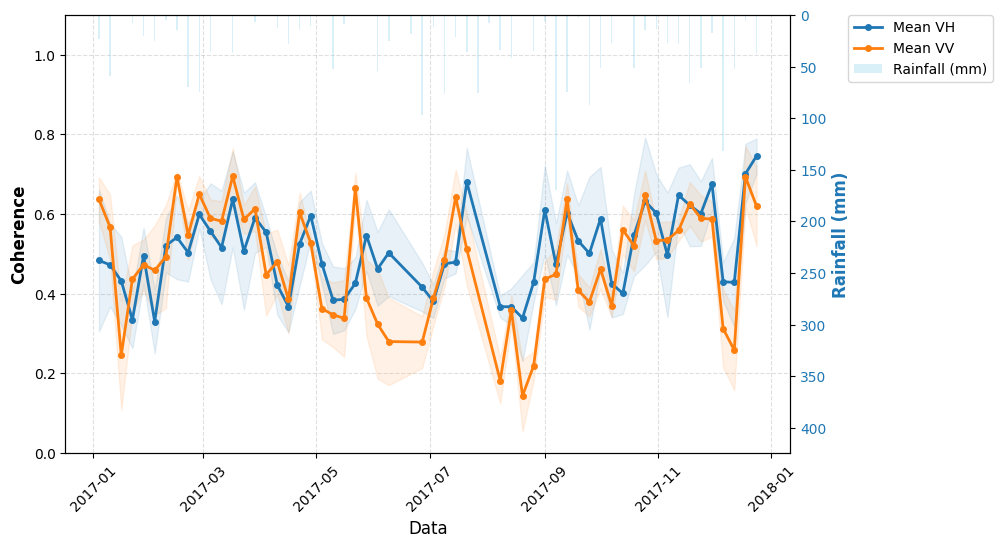

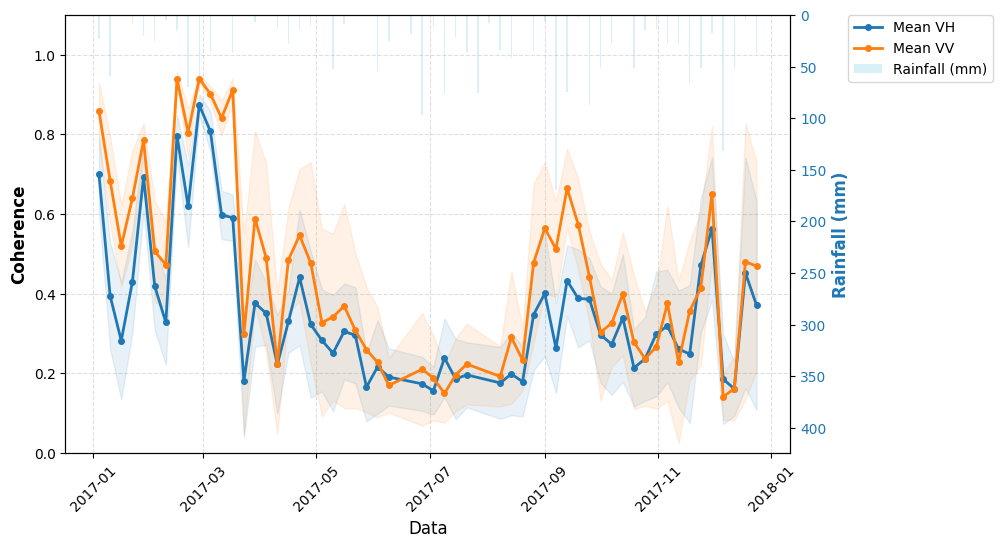

In [108]:
from matplotlib.backends.backend_pdf import PdfPages
# 1. Trasformazione del dizionario in DataFrame (Formato Lungo)
# Definisci il nome del file di uscita

output_folder = app_path / 'Documents'
output_folder.mkdir(parents=True, exist_ok=True)

pdf_filename = output_folder / 'TS_Coherence_Rain.pdf'

unique_rois = df_stats['Code'].unique()

for (roi), group in df_stats.groupby(['Code']):
    # 1. Prepariamo la figura e gli assi
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Filtriamo i dati ROI
    roi_data = df_stats[df_stats['Code'] == roi]
    
    
    # --- SICUREZZA DATE ---
    # Filtriamo le piogge per mostrare solo lo stesso periodo della coerenza
    min_date = roi_data['Date'].min()
    max_date = roi_data['Date'].max()
    rain_filtered = df_weekly[(df_weekly.index >= min_date) & (df_weekly.index <= max_date)]

    # --- ASSE 2: PIOGGIA (Sotto le linee) ---
    ax2 = ax1.twinx()
    # Usiamo zorder=1 per metterlo sullo sfondo
    ax2.bar(rain_filtered.index, rain_filtered.iloc[:,0], 
            color='skyblue', alpha=0.3, label='Rainfall (mm)', width=0.8, zorder=1)
    
    ax2.set_ylabel("Rainfall (mm)", color='tab:blue', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    
    # Spazio sopra le barre per non coprire le linee (regola il moltiplicatore se serve)
    if not rain_filtered.empty and rain_filtered.iloc[:,0].max() > 0:
        ax2.set_ylim(0, rain_filtered.iloc[:,0].max() * 2.5)
    ax2.invert_yaxis() 

    # --- ASSE 1: COERENZA (Sopra le barre) ---
    # Portiamo ax1 davanti a ax2
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False) # Rende ax1 trasparente per vedere ax2 sotto
    
    for band in roi_data['Band'].unique():
        band_data = roi_data[roi_data['Band'] == band]
        line, = ax1.plot(band_data['Date'], band_data['mean'], 
                            marker='o', markersize=4, linestyle='-', linewidth=2, 
                            label=f'Mean {band}', zorder=3)
        
        ax1.fill_between(
            band_data['Date'], 
            band_data['mean'] - band_data['std'], 
            band_data['mean'] + band_data['std'], 
            color=line.get_color(), 
            alpha=0.1, zorder=2
        )

    ax1.set_ylabel("Coherence", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Data", fontsize=12)
    ax1.set_ylim(0, 1.1) # La coerenza di solito sta tra 0 e 1

    # --- LEGENDA E LAYOUT ---
    # Uniamo le labels di entrambi gli assi
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    
    # Spostiamo la legenda leggermente più a destra e usiamo subplots_adjust
    ax1.legend(h1 + h2, l1 + l2, loc='upper left', bbox_to_anchor=(1.08, 1), borderaxespad=0.)

    ax1.grid(True, linestyle='--', alpha=0.4)
    
    # Ruotiamo le date sull'asse X
    plt.setp(ax1.get_xticklabels(), rotation=45)
    
    # Invece di tight_layout puro, usiamo margin per far spazio alla legenda
    plt.subplots_adjust(right=0.85, bottom=0.15)
    
